In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score


import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

<Axes: >

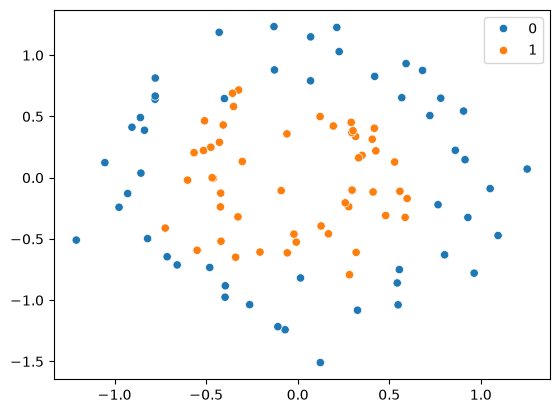

In [15]:
X, y = make_circles(n_samples=100, factor=0.5, noise=0.15, random_state=0)
sns.scatterplot(x = X[:, 0],y = X[:, 1], hue = y)

In [17]:
c_scale = [[0, "rgb(247, 168, 84)"], [1, "rgb(209, 0, 0)"]]

def create_scatter(x, y, plot_type):
    
    return go.Scatter3d(
                x=x[:, 0], y=x[:, 1], z=y,
                mode="markers",
                marker=dict(
                    size=6,
                    color=y,
                    colorscale=c_scale if plot_type == "pred" else "Blugrn",
                    line=dict(width=4, color="White"),
                ),
            )

def format_plot(fig):
  return fig.update_layout(
      scene=dict(
          xaxis_title="x1", 
          yaxis_title="x2", 
          zaxis_title="y"
      ),
      height=400,
      width=600,
      margin=dict(l=10, r=10, t=40, b=20),
  )

fig = go.Figure()
fig.add_trace(create_scatter(X, y, "pred"))
fig = format_plot(fig)
fig.show()

In [23]:
class MyGradientBoostingClassifier:
    
    def __init__(self, learning_rate, n_estimators, max_depth=1):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
        
    def fit(self, X, y):
        
        F0 = np.log(y.mean()/(1-y.mean()))  # log-odds values
        self.F0 = F0  # scalar base score
        Fm = np.full(len(y), self.F0)
        
        for _ in range(self.n_estimators):
            p = np.exp(Fm) / (1 + np.exp(Fm))  # converting back to probabilities
            r = y - p  # residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=0)
            tree.fit(X, r)
            ids = tree.apply(X)  # getting the terminal node IDs

            # looping through the terminal nodes 
            for j in np.unique(ids):
              fltr = ids == j

              # getting gamma using the formula (Σresiduals/Σp(1-p))
              num = r[fltr].sum()
              den = (p[fltr]*(1-p[fltr])).sum()
              gamma = num / den

              # updating the prediction
              Fm[fltr] += self.learning_rate * gamma

              # replacing the prediction value in the tree
              tree.tree_.value[j, 0, 0] = gamma

            self.trees.append(tree)
            
    def predict_proba(self, X):
        
        Fm = np.full(len(X), self.F0)
        
        for i in range(self.n_estimators):
            Fm += self.learning_rate * self.trees[i].predict(X)
            
        return np.exp(Fm) / (1 + np.exp(Fm))  # converting back to probabilities

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [37]:
clf = MyGradientBoostingClassifier(learning_rate= 0.1, n_estimators=50, max_depth=5)

clf.fit(X_train, y_train)

pred_prob = clf.predict_proba(X_test)

pred = np.where(pred_prob > 0.5, 1, 0)

accuracy_score(y_test, pred)

0.9